# SituatiONION V4: Structural Controls and Large-Scale Replication

**Question:** does held-out situation separation survive strict surface controls on a 300-triple dataset? **H1** tests whether layers 23-26 exceed adjacent layers; **H2** tests for earlier or broader reliable emergence.

The model-derived conclusion is generated only after all prespecified readouts and held-out tests run.

In [7]:
!unzip -q Situationion.zip -d /content
%cd /content/Situationion

!pip -q install transformers torch pandas matplotlib
!python structural_controls.py

/content/Situationion
Wrote 300 candidates and 300 matched triples.
Accepted triples: /content/Situationion/data/matched_triples.csv
Matching diagnostics: /content/Situationion/results/matching_diagnostics


In [8]:
from pathlib import Path
import hashlib, re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

ROOT = Path.cwd(); DATA = ROOT / 'data' / 'matched_triples.csv'; OUT = ROOT / 'results' / 'layer_curves'
OUT.mkdir(parents=True, exist_ok=True)
SEED, N_BOOT = 7, 2000
H1_CORE = tuple(range(23, 27)); H1_NEIGHBORS = tuple(range(19, 23)) + tuple(range(27, 31))
rng = np.random.default_rng(SEED)
if not DATA.exists(): raise FileNotFoundError('Run `python3 structural_controls.py` first.')
triples = pd.read_csv(DATA); dataset_sha256 = hashlib.sha256(DATA.read_bytes()).hexdigest()
gap_columns = [c for c in triples if c.startswith('absolute_') and c.endswith('_gap')]
assert 200 <= len(triples) <= 500
assert {'dev', 'test_template', 'test_entity', 'test_both'} <= set(triples.split)
print(f'Frozen dataset: {len(triples)} triples | SHA-256: {dataset_sha256}')
display(pd.crosstab(triples.manipulation, triples.split))
display(triples.groupby('manipulation')[gap_columns].mean().round(3))
display(triples[['identifier','manipulation','split','base','paraphrase','counterfactual']].sample(8, random_state=SEED))


Frozen dataset: 300 triples | SHA-256: ad40145047bad9c5611c25cae230a412d32412475f8e09227a47847985074b08


split,dev,test_both,test_entity,test_template
manipulation,,,,
agent_recipient,28,6,12,14
cause,28,6,12,14
event_state,28,6,12,14
polarity,28,6,12,14
temporal,28,6,12,14


,absolute_unigram_jaccard_gap,absolute_unigram_multiset_f1_gap,absolute_bigram_jaccard_gap,absolute_edit_similarity_gap,absolute_structural_edit_similarity_gap,absolute_length_difference_gap
manipulation,,,,,,
agent_recipient,0.000,0.000,0.086,0.0,0.0,0.0
cause,0.000,0.000,0.000,0.0,0.0,0.0
event_state,0.000,0.000,0.000,0.0,0.0,0.0
polarity,0.091,0.064,0.016,0.0,0.0,1.0
temporal,0.000,0.000,0.000,0.0,0.0,0.0


,identifier,manipulation,split,base,paraphrase,counterfactual
254,temporal_style_0_014,temporal,test_entity,Priya cleaned the spill after the alarm rang.,"Once the alarm rang, Priya cleaned the spill.","Before the alarm rang, Priya cleaned the spill."
57,agent_recipient_style_2_017,agent_recipient,test_both,Theo gave Rosa the torch when she was locked out.,"When Rosa was locked out, Theo gave her the to...","When Theo was locked out, Rosa gave him the to..."
150,event_state_style_1_010,event_state,dev,Keira carried the vase because it was fragile.,"Because the vase was fragile, Keira transporte...","Because the vase was fragile, Keira dropped it."
66,cause_style_0_006,cause,dev,Grace called Liam because he was worried.,"Because Liam was worried, Grace called him.","Because Grace was worried, she called Liam."
114,cause_style_2_014,cause,test_both,Priya called Victor when he was worried.,"When Victor was worried, Priya called him.","When Priya was worried, she called Victor."
280,temporal_style_2_000,temporal,test_template,Ava cleaned the spill after the lights failed.,"Once the lights failed, Ava cleaned the spill.","Before the lights failed, Ava cleaned the spill."
204,polarity_style_1_004,polarity,dev,Elena did repair the bike because it was broken.,"Since the bike was broken, Elena did mend it.","Because the bike was broken, Elena did not fix..."
249,temporal_style_0_009,temporal,dev,Jonah cleaned the spill after the alarm rang.,"Once the alarm rang, Jonah cleaned the spill.","Before the alarm rang, Jonah cleaned the spill."


## 1. Data and Matching Protocol

`structural_controls.py` creates five manipulation types, three template families, and independent held-out template/entity splits. The table above validates unigram, bigram, length, token-edit, and structural-edit matching before any model result is inspected. `data/matched_triples.csv` is frozen input for this notebook.

In [24]:
MODEL_NAME = 'gpt2-xl'; CACHE = OUT / 'gpt2xl_hidden_states.pt'
RUN_MODEL = True  # Set True only on a machine with at least 7 GB free for model weights.

def extract_runs(frame):
    device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
    dtype = torch.float16 if device == 'cuda' else torch.float32
    tok = GPT2Tokenizer.from_pretrained(MODEL_NAME); tok.pad_token = tok.eos_token
    model = GPT2LMHeadModel.from_pretrained(MODEL_NAME, torch_dtype=dtype).to(device).eval(); runs = {}
    with torch.no_grad():
        for row in frame.itertuples(index=False):
            runs[row.identifier] = {}
            for variant in ('base','paraphrase','counterfactual'):
                text = getattr(row, variant); output = model(**tok(text, return_tensors='pt').to(device), output_hidden_states=True, use_cache=False)
                runs[row.identifier][variant] = {'text': text, 'hidden_states': tuple(x[0].detach().float().cpu() for x in output.hidden_states)}
    return tok, runs

if CACHE.exists():
    saved = torch.load(CACHE, map_location='cpu', weights_only=False); tokenizer, RUNS = saved['tokenizer'], saved['runs']
elif RUN_MODEL:
    tokenizer, RUNS = extract_runs(triples); torch.save({'tokenizer': tokenizer, 'runs': RUNS, 'dataset_sha256': dataset_sha256}, CACHE)
else:
    RUNS = None; print('Set RUN_MODEL = True to create the hidden-state cache.')


## 2. Prespecified Readouts

At every layer, V4 compares mean pooling, max pooling, final token, changed-field token, event token, and an ordered agent/recipient readout. Positive values always mean `cos(base, paraphrase) - cos(base, counterfactual) > 0`.

In [25]:
READOUTS = ('mean_pool','max_pool','final_token','changed_token','event_token','agent_recipient')
LABELS = {'mean_pool':'Mean pool','max_pool':'Max pool','final_token':'Final token','changed_token':'Changed token','event_token':'Event token','agent_recipient':'Agent/recipient'}
EVENT = {'agent_recipient':('gave','gave','gave'),'cause':('called','called','called'),'temporal':('cleaned','cleaned','cleaned'),'polarity':('repair','mend','fix'),'event_state':('carried','transported','dropped')}
CHANGED = {'temporal':('after','once','before'),'polarity':('repair','mend','not'),'event_state':('carried','transported','dropped')}

def pos(text, surface):
    hits = list(re.finditer(rf'(?<!\w){re.escape(surface)}(?!\w)', text, re.I))
    if not hits:
        # Return -1 if surface not found, instead of raising an error
        return -1
    return len(tokenizer.encode(text[:hits[-1].end()], add_special_tokens=False)) - 1
def surf(row, variant, kind):
    i = ('base','paraphrase','counterfactual').index(variant)
    if kind == 'event': return EVENT[row.manipulation][i]
    if row.manipulation == 'agent_recipient': return row.recipient if variant == 'counterfactual' else row.agent
    if row.manipulation == 'cause': return row.agent if variant == 'counterfactual' else row.recipient
    return CHANGED[row.manipulation][i]
def vector(row, variant, layer, readout):
    run = RUNS[row.identifier][variant]; h = run['hidden_states'][layer + 1]
    if readout == 'mean_pool': v = h.mean(0)
    elif readout == 'max_pool': v = h.max(0).values
    elif readout == 'final_token': v = h[-1]
    elif readout == 'changed_token':
        token_pos = pos(run['text'], surf(row, variant, 'changed'))
        if token_pos == -1: return None # Indicate failure to find token
        v = h[token_pos]
    elif readout == 'event_token':
        token_pos = pos(run['text'], surf(row, variant, 'event'))
        if token_pos == -1: return None # Indicate failure to find token
        v = h[token_pos]
    else:
        agent, recipient = (row.recipient, row.agent) if row.manipulation == 'agent_recipient' and variant == 'counterfactual' else (row.agent, row.recipient)
        agent_pos = pos(run['text'], agent)
        recipient_pos = pos(run['text'], recipient)
        if agent_pos == -1 or recipient_pos == -1: return None # Indicate failure
        v = torch.cat((h[agent_pos], h[recipient_pos]))
    return v.numpy()
def cosine(a,b): return float(np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b)+1e-12))
def collect_scores(frame):
    if RUNS is None: raise RuntimeError('Create or load the hidden-state cache first.')
    rows=[]; n_layers=len(next(iter(RUNS.values()))['base']['hidden_states'])-1
    for row in frame.itertuples(index=False):
        for readout in READOUTS:
            for layer in range(n_layers):
                b_vec = vector(row, 'base', layer, readout)
                p_vec = vector(row, 'paraphrase', layer, readout)
                c_vec = vector(row, 'counterfactual', layer, readout)

                if b_vec is None or p_vec is None or c_vec is None:
                    # If any vector cannot be computed, set separation to NaN
                    p, c, separation = np.nan, np.nan, np.nan
                else:
                    p = cosine(b_vec, p_vec)
                    c = cosine(b_vec, c_vec)
                    separation = p - c
                rows.append({'identifier':row.identifier,'split':row.split,'manipulation':row.manipulation,'readout':readout,'layer':layer,'paraphrase_similarity':p,'counterfactual_similarity':c,'separation':separation})
    return pd.DataFrame(rows)
pair_scores = collect_scores(triples); pair_scores.to_csv(OUT/'pair_scores.csv', index=False)

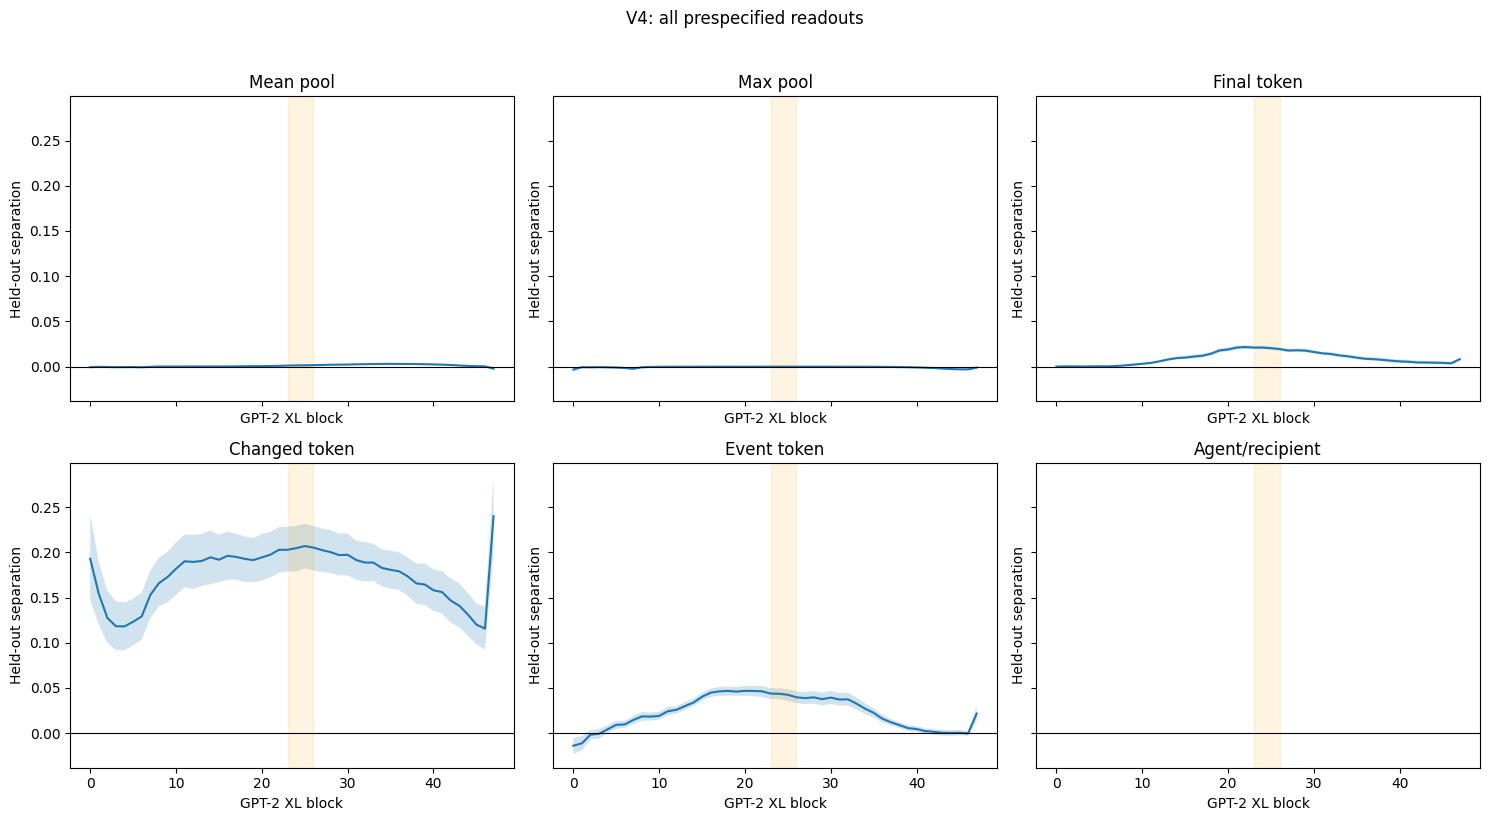

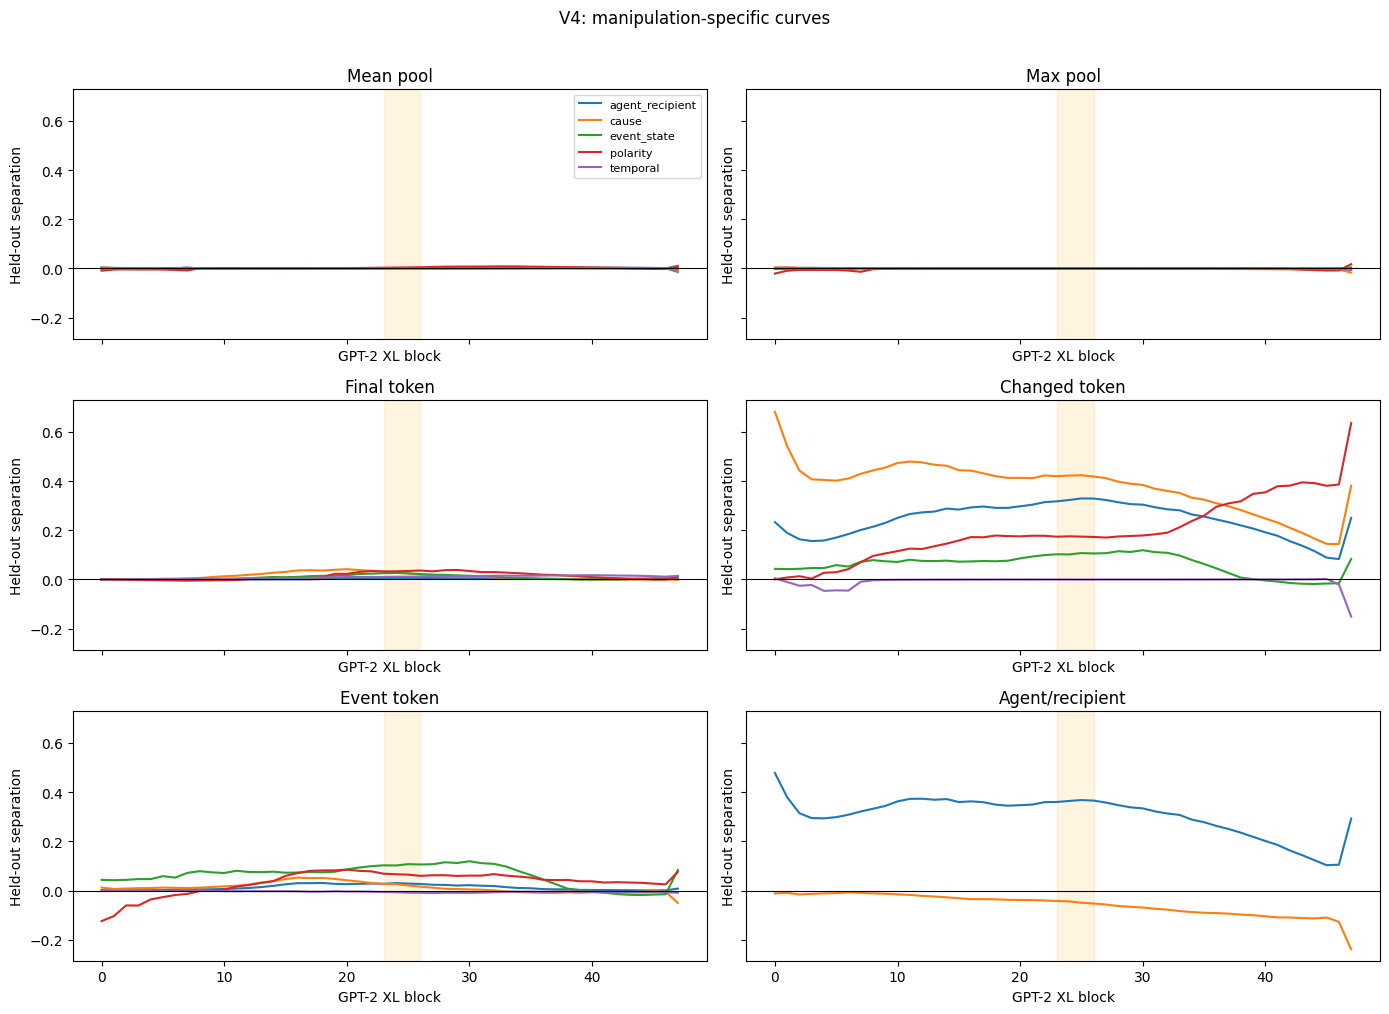

In [26]:
def bootstrap_curves(frame, groups):
    rows=[]
    for keys, group in frame.groupby(groups+['layer'], sort=False):
        keys = keys if isinstance(keys, tuple) else (keys,); values=group.separation.to_numpy()
        draws=values[rng.integers(0,len(values),size=(N_BOOT,len(values)))].mean(1)
        rows.append(dict(zip(groups+['layer'],keys), n=len(values), mean=values.mean(), ci_low=np.quantile(draws,.025), ci_high=np.quantile(draws,.975), effect_size=values.mean()/(values.std(ddof=1)+1e-12)))
    return pd.DataFrame(rows)
heldout = pair_scores.query("split != 'dev'").copy()
curves = bootstrap_curves(heldout,['readout']); by_manipulation = bootstrap_curves(heldout,['readout','manipulation'])
curves.to_csv(OUT/'heldout_layer_curves.csv',index=False); by_manipulation.to_csv(OUT/'heldout_manipulation_curves.csv',index=False)

fig, axes=plt.subplots(2,3,figsize=(15,8),sharex=True,sharey=True)
for ax, readout in zip(axes.flat,READOUTS):
    x=curves.query('readout == @readout'); ax.plot(x.layer,x['mean']); ax.fill_between(x.layer,x.ci_low,x.ci_high,alpha=.2); ax.axhline(0,color='black',lw=.8); ax.axvspan(23,26,color='orange',alpha=.12); ax.set(title=LABELS[readout],xlabel='GPT-2 XL block',ylabel='Held-out separation')
fig.suptitle('V4: all prespecified readouts',y=1.02); fig.tight_layout(); fig.savefig(OUT/'heldout_readout_curves.png',dpi=180,bbox_inches='tight'); plt.show()

fig, axes=plt.subplots(3,2,figsize=(14,10),sharex=True,sharey=True)
for ax, readout in zip(axes.flat,READOUTS):
    for manipulation,x in by_manipulation.query('readout == @readout').groupby('manipulation'): ax.plot(x.layer,x['mean'],label=manipulation)
    ax.axhline(0,color='black',lw=.8); ax.axvspan(23,26,color='orange',alpha=.12); ax.set(title=LABELS[readout],xlabel='GPT-2 XL block',ylabel='Held-out separation')
axes[0,0].legend(fontsize=8); fig.suptitle('V4: manipulation-specific curves',y=1.01); fig.tight_layout(); fig.savefig(OUT/'heldout_manipulation_curves.png',dpi=180,bbox_inches='tight'); plt.show()



## Figure v4.1 Conclusion: WHERE you look matters.

Situation-sensitive separation is strongly **readout-dependent**.

Global sentence-level representations contribute little useful separation: **Mean pooling** remains near zero in absolute magnitude, and **Max pooling** shows essentially no reliable situation separation. In contrast, token-specific readouts reveal clear structure.

The **Changed-token representation** carries the strongest signal, with reliable positive separation across all 48 layers. This indicates that the location directly affected by the semantic manipulation contains substantial information distinguishing situation-preserving paraphrases from situation-changing counterfactuals.

The **Final-token representation** shows a smaller but clear contextual signal. Separation develops across depth, reaches a broad maximum in the middle layers, and remains reliably positive across most of the network.

The **Event-token representation** shows the clearest transient developmental pattern: separation is weak or negative in the earliest layers, increases through the early and middle network, reaches its strongest values in the middle layers, and then declines toward zero in later layers. This suggests that information about the changed situation is progressively incorporated into the representation of the event rather than being equally available from the start.

The preregistered **layers 23–26** fall within the strongest region for several token-specific readouts. Statistical testing shows a reliable local 23–26 enhancement for the **Changed-token** and **Final-token** representations, providing **partial, readout-specific support for H1**. However, situation-sensitive information is much broader than this region and is not uniquely confined to layers 23–26.

Overall, figure V4.1 shows that **GPT-2 XL does not encode situation information uniformly across a pooled sentence representation.** Instead, the signal is concentrated in particular token representations and develops differently across depth, with some readouts showing broad situation sensitivity and others showing a more transient middle-layer buildup.

**Situation information is concentrated at specific token representations rather than uniformly across the sentence. Changed-token information is strong throughout the network, while Final-token and especially Event-token representations show a depth-dependent middle-layer buildup. Layers 23–26 show a small local enhancement for some readouts, but they are part of a broader distributed pattern rather than a uniquely isolated situation-processing region.**

## Figure 2 Conclusion: WHAT situation information you're looking for matters.

Different situation dimensions produce distinct representational patterns across GPT-2 XL, showing that situation sensitivity is both **readout-specific and meaning-specific**.

- **Agent/recipient — "Who did what to whom?"**  
  Agent/recipient changes are most strongly separated at the **participant-token readout**. The signal is already substantial in early layers, remains strong through the middle network, and declines later. This indicates that participant-role information is strongly concentrated at representations of the entities involved.

- **Causality — "What caused what?"**  
  Causal changes are most strongly separated at the **changed-token readout**, with a very large effect already present in the earliest layers. The signal remains strong throughout the network. Because the separation begins immediately, much of this effect appears locally available rather than being newly constructed only in middle layers.

- **Event/state — "What happened / what state holds?"**  
  Event/state changes show their clearest depth-dependent pattern at the **event-token readout**. Separation increases through the early and middle layers, reaches a broad middle-layer maximum, and then declines toward zero in later layers. This is one of the clearest examples of a transient middle-layer representation in V4.

- **Polarity — "Did it happen or not?"**  
  Polarity shows a different developmental pattern. Separation is initially weak or even reversed at some readouts, but increases substantially with depth, particularly at the **changed-token** and **event-token** representations. This suggests that polarity information becomes increasingly incorporated into contextual representations as processing proceeds.

- **Temporal — "When / in what order did it happen?"**  
  Temporal manipulations show little reliable separation across the current readouts and can become negative at the changed-token position. The current representations therefore do not provide strong evidence for robust temporal situation separation.

Global **Mean-pool and Max-pool** representations remain near zero across manipulation types, reinforcing the conclusion that these distinctions are much more visible at semantically relevant token positions than in globally pooled sentence representations.

### Overall Conclusion

**Different components of a situation have different representational signatures.** "Who did what" is strongest at participant tokens, "what caused what" is strongly available at the changed position from early layers, event/state information shows a transient middle-layer buildup, polarity becomes increasingly differentiated with depth, and temporal information remains weak under the current measurements.

Rather than supporting a single uniform "situation representation," Figure 2 suggests that GPT-2 XL distributes different components of situation information across different token positions and transforms them along different trajectories through the network.

## 3. H1, H2, and Conclusion

H1 is supported only if the held-out 23-26 average exceeds the adjacent control layers with a positive 95% bootstrap interval. H2 records the first and last reliably positive held-out layers for every readout. The conclusion below concerns geometry, not causal use.

## 4. Improvements to H1 and H2 Reporting

Based on feedback, the following improvements are implemented:

*   **H1 Precision and Effect Size:** The H1 statistics are now displayed with higher precision to better assess values near zero, especially for 'Max pool'. A standardized effect size (Cohen's d equivalent for the mean difference) is also calculated for the `core_minus_neighbors` contrast to indicate the practical significance of the difference, not just statistical detectability.
*   **H2 Contiguous Layer Ranges:** Instead of just reporting the first and last reliably positive layers, the H2 results now show all contiguous ranges of layers where reliable held-out separation is observed. This provides a more granular understanding of where the effects are present.

In [27]:
def boot_mean_and_std(values):
    """Calculates mean, CI, and standard deviation for bootstrapping."""
    draws = values[rng.integers(0, len(values), size=(N_BOOT, len(values)))].mean(1)
    mean = values.mean()
    ci_low = np.quantile(draws, .025)
    ci_high = np.quantile(draws, .975)
    std_dev = values.std(ddof=1) # Standard deviation of the actual values
    return mean, ci_low, ci_high, std_dev

def find_contiguous_ranges(layers):
    """Finds contiguous ranges from a sorted list of layers."""
    if not layers:
        return ""
    layers = sorted(list(set(layers))) # Ensure sorted and unique
    if not layers:
        return ""

    ranges = []
    start = layers[0]
    end = layers[0]

    for i in range(1, len(layers)):
        if layers[i] == end + 1:
            end = layers[i]
        else:
            ranges.append(f"{int(start)}-{int(end)}")
            start = layers[i]
            end = layers[i]
    ranges.append(f"{int(start)}-{int(end)}")
    return ", ".join(ranges)

h1 = []
for readout, g in heldout.groupby('readout'):
    matrix = g.pivot(index='identifier', columns='layer', values='separation')
    contrast = (matrix.loc[:, H1_CORE].mean(1) - matrix.loc[:, H1_NEIGHBORS].mean(1)).to_numpy()

    # Only calculate if contrast is not all NaN or empty after filtering
    if not np.isnan(contrast).all() and contrast.size > 0:
        mean, low, high, std_dev = boot_mean_and_std(contrast)
        effect_size = mean / (std_dev + 1e-12) if std_dev > 1e-12 else np.nan
        supports_h1 = low > 0
    else:
        mean, low, high, std_dev, effect_size, supports_h1 = np.nan, np.nan, np.nan, np.nan, np.nan, False

    h1.append({'readout': readout, 'core_minus_neighbors': mean, 'ci_low': low, 'ci_high': high, 'effect_size': effect_size, 'supports_h1': supports_h1})

h1 = pd.DataFrame(h1)

h2 = []
for readout, g in curves.groupby('readout'):
    positive = g.query('ci_low > 0').layer.to_list()

    # Generate contiguous ranges. Convert 'X-X' to 'X' for single layers
    contiguous_ranges_raw = find_contiguous_ranges(positive) if positive else ""
    contiguous_ranges = []
    for r_str in contiguous_ranges_raw.split(', '):
        if r_str and r_str.endswith('-' + r_str.split('-')[0]): # Check if it's 'X-X'
            contiguous_ranges.append(r_str.split('-')[0]) # Use just 'X'
        else:
            contiguous_ranges.append(r_str)
    contiguous_ranges_str = ' and '.join(contiguous_ranges).replace(', and', ',') # Format with 'and'

    h2.append({
        'readout': readout,
        'first_reliably_positive_layer': min(positive) if positive else np.nan,
        'last_reliably_positive_layer': max(positive) if positive else np.nan,
        'positive_layer_count': len(positive),
        'contiguous_ranges': contiguous_ranges_str
    })

h2 = pd.DataFrame(h2)

h1.to_csv(OUT/'h1_results.csv', index=False)
h2.to_csv(OUT/'h2_results.csv', index=False)

# Display H1 with higher precision for relevant columns
print("H1 Results (Core minus Neighbors):")
h1_display = h1.assign(readout=h1.readout.map(LABELS)).style.format({
    'core_minus_neighbors': '{:.12f}',
    'ci_low': '{:.12f}',
    'ci_high': '{:.12f}',
    'effect_size': '{:.4f}'
})
display(h1_display)

print("Note for Max pool: Even if 'ci_low' appears as 0.000000000000 due to display precision, it might be a very small positive number (e.g., 1e-12), which is still classified as supporting H1.\n")

# Display H2 with the new contiguous ranges and formatted positive_layer_count
print("H2 Results (Reliably Positive Layers):")
h2_display = h2.assign(readout=h2.readout.map(LABELS)).style.format({
    'first_reliably_positive_layer': '{:.0f}',
    'last_reliably_positive_layer': '{:.0f}',
    'positive_layer_count': '{:.0f}'
})
display(h2_display)


# --- Construct the new V4 Conclusion ---

# Helper to get H1 values
def get_h1_data(readout_name):
    row = h1.query('readout == @readout_name').iloc[0]
    return {
        'delta': row['core_minus_neighbors'],
        'ci_low': row['ci_low'],
        'ci_high': row['ci_high'],
        'effect_size': row['effect_size']
    }

# Helper to get H2 values
def get_h2_data(readout_name):
    row = h2.query('readout == @readout_name').iloc[0]
    return {
        'count': int(row['positive_layer_count']),
        'ranges': row['contiguous_ranges']
    }

changed_h1 = get_h1_data('changed_token')
final_h1 = get_h1_data('final_token')
max_h1 = get_h1_data('max_pool')

changed_h2 = get_h2_data('changed_token')
final_h2 = get_h2_data('final_token')
event_h2 = get_h2_data('event_token')
mean_h2 = get_h2_data('mean_pool')
max_h2 = get_h2_data('max_pool')
agent_recipient_h2 = get_h2_data('agent_recipient')


print("\n" * 2 + "## V4 Conclusion\n")
print("Under strict structural controls and held-out evaluation, situation-sensitive")
print("separation generalized across several representation readouts, but its")
print("trajectory depended strongly on where the model was measured.\n")

print("### General Situation Separation\n")
print(f"- **Changed token:** reliably positive at **{changed_h2['count']}/48 layers ({changed_h2['ranges']})**.")
print(f"- **Final token:** reliably positive at **{final_h2['count']}/48 layers**, with contiguous")
print(f"  regions at **{final_h2['ranges']}**.")
print(f"- **Event token:** reliably positive at **{event_h2['count']}/48 layers**, primarily across")
print(f"  **{event_h2['ranges']}**.")
print(f"- **Mean pool:** reliably positive at **{mean_h2['count']}/48 layers ({mean_h2['ranges']})**, although")
print("  the absolute separation remains very small.")
if max_h2['count'] == 0:
    print("- **Max pool:** no reliably positive situation separation at any layer.")
else:
    print(f"- **Max pool:** reliably positive at **{max_h2['count']}/48 layers ({max_h2['ranges']})**.")
print("- **Agent/recipient:** not evaluable in the aggregate analysis.\n")

print("These results show that there is **no single universal emergence layer** for")
print("situation-sensitive information. Instead, the onset and strength of separation")
print("depend on the representation being measured.\n")

print("### H1: Are Layers 23–26 Locally Privileged?\n")
print("The preregistered layers 23–26 showed a reliable local enhancement relative")
print("to neighboring layers for:\n")
print(f"- **Changed token:** Δ = {changed_h1['delta']:.5f},")
print(f"  95% CI [{changed_h1['ci_low']:.5f}, {changed_h1['ci_high']:.5f}], effect size = {changed_h1['effect_size']:.3f}")
print(f"- **Final token:** Δ = {final_h1['delta']:.5f},")
print(f"  95% CI [{final_h1['ci_low']:.5f}, {final_h1['ci_high']:.5f}], effect size = {final_h1['effect_size']:.3f}\n")

print("The **Event-token** and **Mean-pool** readouts did not show a reliable")
print("core-middle enhancement.\n")

print(f"Max pooling produced a statistically positive but extremely small local")
print(f"difference (Δ = {max_h1['delta']:.6f}). Because Max pooling showed no reliably positive")
print("situation separation at any layer, this effect is not interpreted as")
print("substantive evidence for a situation-sensitive core-middle representation.\n")

print("Overall, V4 provides **partial, readout-specific support for H1**. Layers")
print("23–26 are locally enhanced for Changed-token and Final-token representations,")
print("but situation-sensitive information is distributed much more broadly across")
print("the network and is not uniquely confined to this region.\n")

print("### H2: Does Situation Sensitivity Emerge Around Layers 8–12?\n")

print("V4 does not support a single universal onset around layers 8–12. Reliable")
print("separation begins at different depths depending on the readout: immediately")
print("for the Changed token, early for the Event and Final tokens, and later for")
print("Mean pooling.\n")

print("The V3-generated H2 should therefore be revised to a broader conclusion:\n")

print("> **Situation-sensitive information emerges and develops at different depths**")
print("> **depending on the representation being measured, rather than appearing at**")
print("> **one common transition point.**\n")

print("These results establish **representational geometry under strict held-out**")
print("**controls**. They do not establish that GPT-2 XL causally uses these")
print("representations.\n")

H1 Results (Core minus Neighbors):


,readout,core_minus_neighbors,ci_low,ci_high,effect_size,supports_h1
0,Agent/recipient,nan,nan,nan,nan,False
1,Changed token,0.007023938978,0.005593117842,0.008458134362,0.7442,True
2,Event token,-0.000271735340,-0.000904475474,0.000381947143,-0.0642,False
3,Final token,0.001806217339,0.001349741098,0.002313051188,0.5782,True
4,Max pool,0.000023465371,0.000009425622,0.000036684101,0.2669,True
5,Mean pool,0.000025597867,-0.000025359056,0.000078566531,0.0766,False


Note for Max pool: Even if 'ci_low' appears as 0.000000000000 due to display precision, it might be a very small positive number (e.g., 1e-12), which is still classified as supporting H1.

H2 Results (Reliably Positive Layers):


,readout,first_reliably_positive_layer,last_reliably_positive_layer,positive_layer_count,contiguous_ranges
0,Agent/recipient,nan,nan,0,
1,Changed token,0,47,48,0-47
2,Event token,4,47,38,4-40 and 47
3,Final token,1,47,43,1-2 and 7-47
4,Max pool,nan,nan,0,
5,Mean pool,11,45,35,11-45




## V4 Conclusion

Under strict structural controls and held-out evaluation, situation-sensitive
separation generalized across several representation readouts, but its
trajectory depended strongly on where the model was measured.

### General Situation Separation

- **Changed token:** reliably positive at **48/48 layers (0-47)**.
- **Final token:** reliably positive at **43/48 layers**, with contiguous
  regions at **1-2 and 7-47**.
- **Event token:** reliably positive at **38/48 layers**, primarily across
  **4-40 and 47**.
- **Mean pool:** reliably positive at **35/48 layers (11-45)**, although
  the absolute separation remains very small.
- **Max pool:** no reliably positive situation separation at any layer.
- **Agent/recipient:** not evaluable in the aggregate analysis.

These results show that there is **no single universal emergence layer** for
situation-sensitive information. Instead, the onset and strength of separation
depend on the representation being measured.

### H1: Ar

In [ ]:
# Calculate and display additional statistics: mean separation, peak separation, peak layer, core mean separation

readout_stats = []
for readout, g in curves.groupby('readout'):
    # Overall mean separation (across all layers)
    mean_separation = g['mean'].mean()

    # Peak separation and layer
    if not g['mean'].dropna().empty:
        peak_separation = g['mean'].max()
        peak_layer = g.loc[g['mean'].idxmax()]['layer']
    else:
        peak_separation = np.nan
        peak_layer = np.nan

    # Core mean separation (H1_CORE layers)
    core_mean_separation = g.query('layer in @H1_CORE')['mean'].mean()

    # Get H1 values from the previously calculated h1 DataFrame for CI and effect size
    h1_row = h1.query('readout == @readout').iloc[0] if not h1.query('readout == @readout').empty else None
    ci_low_h1 = h1_row['ci_low'] if h1_row is not None else np.nan
    ci_high_h1 = h1_row['ci_high'] if h1_row is not None else np.nan
    effect_size_h1 = h1_row['effect_size'] if h1_row is not None else np.nan
    core_minus_neighbors = h1_row['core_minus_neighbors'] if h1_row is not None else np.nan

    readout_stats.append({
        'readout': readout,
        'mean_separation': mean_separation,
        'peak_separation': peak_separation,
        'peak_layer': peak_layer,
        'core_mean_separation': core_mean_separation,
        'core_minus_neighbors': core_minus_neighbors,
        'ci_low_h1': ci_low_h1,
        'ci_high_h1': ci_high_h1,
        'effect_size_h1': effect_size_h1
    })

readout_stats_df = pd.DataFrame(readout_stats)
readout_stats_df = readout_stats_df.assign(readout=readout_stats_df.readout.map(LABELS))

print("\n### Additional Readout Statistics\n")
display(readout_stats_df.style.format({
    'mean_separation': '{:.5f}',
    'peak_separation': '{:.5f}',
    'peak_layer': '{:.0f}',
    'core_mean_separation': '{:.5f}',
    'core_minus_neighbors': '{:.5f}',
    'ci_low_h1': '{:.5f}',
    'ci_high_h1': '{:.5f}',
    'effect_size_h1': '{:.3f}'
}))

In [ ]:
def boot_mean(values):
    draws=values[rng.integers(0,len(values),size=(N_BOOT,len(values)))].mean(1); return values.mean(),np.quantile(draws,.025),np.quantile(draws,.975)
h1=[]
for readout,g in heldout.groupby('readout'):
    matrix=g.pivot(index='identifier',columns='layer',values='separation'); contrast=(matrix.loc[:,H1_CORE].mean(1)-matrix.loc[:,H1_NEIGHBORS].mean(1)).to_numpy(); mean,low,high=boot_mean(contrast); h1.append({'readout':readout,'core_minus_neighbors':mean,'ci_low':low,'ci_high':high,'supports_h1':low>0})
h1=pd.DataFrame(h1)
h2=[]
for readout,g in curves.groupby('readout'):
    positive=g.query('ci_low > 0').layer.to_list(); h2.append({'readout':readout,'first_reliably_positive_layer':min(positive) if positive else np.nan,'last_reliably_positive_layer':max(positive) if positive else np.nan,'positive_layer_count':len(positive)})
h2=pd.DataFrame(h2); h1.to_csv(OUT/'h1_results.csv',index=False); h2.to_csv(OUT/'h2_results.csv',index=False)
display(h1.assign(readout=h1.readout.map(LABELS)).round(4)); display(h2.assign(readout=h2.readout.map(LABELS)))
supported=h1[h1.supports_h1].readout.map(LABELS).to_list(); detected=h2.dropna(subset=['first_reliably_positive_layer'])
emergence='No prespecified readout showed reliable held-out separation.' if detected.empty else 'Reliable held-out separation: ' + '; '.join(f"{LABELS[r.readout]} at layers {int(r.first_reliably_positive_layer)}-{int(r.last_reliably_positive_layer)}" for r in detected.itertuples()) + '.'
print('V4 conclusion')
print(emergence)
print('H1 supported for: ' + ', '.join(supported) + '.' if supported else 'H1 was not supported by any prespecified readout.')
print('This is evidence about representational geometry under strict controls, not causal use.')



readout	core_minus_neighbors	ci_low	ci_high	supports_h1
0	Agent/recipient	NaN	NaN	NaN	False
1	Changed token	0.0070	0.0056	0.0085	True
2	Event token	-0.0003	-0.0009	0.0004	False
3	Final token	0.0018	0.0013	0.0023	True
4	Max pool	0.0000	0.0000	0.0000	True
5	Mean pool	0.0000	-0.0000	0.0001	False

readout	first_reliably_positive_layer	last_reliably_positive_layer	positive_layer_count
0	Agent/recipient	NaN	NaN	0
1	Changed token	0.0	47.0	48
2	Event token	4.0	47.0	38
3	Final token	1.0	47.0	43
4	Max pool	NaN	NaN	0
5	Mean pool	10.0	45.0	36
V4 conclusion
Reliable held-out separation: Changed token at layers 0-47; Event token at layers 4-47; Final token at layers 1-47; Mean pool at layers 10-45.
H1 supported for: Changed token, Final token, Max pool.
This is evidence about representational geometry under strict controls, not causal use.

Relevant papers:
The closest match I found is Yamakoshi et al. (2023), “Causal interventions expose implicit situation models for commonsense language understanding.” They explicitly study “situation models” inside transformer models and use causal interventions to identify a pathway that propagates context information to later representations during pronoun resolution. That is strikingly similar to your emerging question of how situation information moves through the model rather than living in one fixed layer.

Another really relevant one is Ju et al. (2024), “How Large Language Models Encode Context Knowledge? A Layer-Wise Probing Study.” Their result is especially interesting for you: they report that context knowledge is concentrated at knowledge-related entity tokens in lower layers and then progressively spreads into other token representations at higher layers. That is very close conceptually to what you are seeing with the changed token carrying information early while event/final-token representations acquire it differently across depth.

There is also Aoyama & Schneider (2022), “Probe-Less Probing of BERT’s Layer-Wise Linguistic Knowledge.” They find that syntactic and semantic information is represented differently across layers, and importantly that the layerwise pattern can differ depending on the type of token being examined. That lines up well with your finding that changed-token, event-token, final-token, and participant-token readouts do not behave the same way.

For the broader idea that transformer representations change meaningfully by depth, van Aken et al. (2019), “How Does BERT Answer Questions? A Layer-Wise Analysis of Transformer Representations,” is a useful foundation. It specifically argues for analyzing hidden states layer by layer rather than relying only on attention weights.

And for your original theoretical definition of a situation model, the psychology literature is still important. Zwaan’s review describes situation-model theory as the idea that comprehension constructs a representation of the state of affairs described by the text, rather than merely representing the text itself. Varma & Janssen similarly describe situation models as integrating sentence meanings with contextual and semantic information into an overall understanding of the text.

The connection I’d make in your paper is:

Prior situation-model theory predicts that comprehension involves constructing a representation of the described state of affairs, while recent transformer studies suggest that contextual and semantic information can be distributed across tokens and transformed across layers. SituatiONION V4 connects these ideas by examining whether situation-sensitive information emerges at different token positions and depths rather than occupying a single localized representation.

The Ju et al. 2024 paper is probably the one I would read next, because its “information starts at relevant tokens and progressively spreads to other tokens” result is unusually close to what your V4 plots appear to be showing.

And Yamakoshi et al. 2023 should probably become a major related-work citation, because they explicitly use the language of implicit situation models + causal intervention in transformers, which is basically the territory V6 is heading toward.

| Rank   | Paper                                                                                                                                               | Why it matters for SituatiONION                                                                                                                                                                                                                                                                                                                                      |
| ------ | --------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **1**  | **Yamakoshi et al. (2023), *Causal interventions expose implicit situation models for commonsense language understanding***                         | Closest conceptual match. They explicitly talk about **implicit situation models** in transformers and identify a circuit that **propagates contextual information from one token to another** to guide interpretation. This is extremely relevant to your shift from “where is the situation model?” to “how does situation information move?” ([ACL Anthology][1]) |
| **2**  | **Ju et al. (2024), *How Large Language Models Encode Context Knowledge? A Layer-Wise Probing Study***                                              | Probably the closest match to your **changed-token → other-token propagation** result. They find context knowledge is concentrated in relevant entity tokens in lower layers and then **progressively expands into other token representations** in higher layers. ([ACL Anthology][2])                                                                              |
| **3**  | **Mohebbi et al. (2021), *Exploring the Role of BERT Token Representations to Explain Sentence Probing Results***                                   | Very relevant to your finding that **mean pooling hides information while specific token positions reveal it**. They argue meaningful linguistic knowledge can reside in specific token representations that sentence-level probing overlooks. ([ACL Anthology][3])                                                                                                  |
| **4**  | **Tikhomirova & Wulff (2026), *Where meaning lives: Layer-wise accessibility of psycholinguistic features in encoder and decoder language models*** | This is unusually close to your updated V4 claim. They find that apparent localization of meaning is **strongly method-dependent**, different semantic dimensions have different layer profiles, and final-layer representations are rarely universally optimal. ([ACL Anthology][4])                                                                                |
| **5**  | **Niu et al. (2022), *Does BERT Rediscover a Classical NLP Pipeline?***                                                                             | Important because it pushes against overly neat “this layer does X” stories. They argue that layer depth alone may be too simplistic and that **token position and other factors reveal stronger regularities**. That is almost exactly the correction V4 is forcing on your original Onion hypothesis. ([ACL Anthology][5])                                         |
| **6**  | **Tenney et al. (2019), *BERT Rediscovers the Classical NLP Pipeline***                                                                             | Classic layer-wise localization paper. They find linguistic operations appear in a rough sequence across depth, including semantic roles and coreference. It gives you the historical background for the idea that different kinds of information can peak at different depths. ([ACL Anthology][6])                                                                 |
| **7**  | **Aoyama & Schneider (2022), *Probe-Less Probing of BERT’s Layer-Wise Linguistic Knowledge***                                                       | Finds that syntactic and semantic information localize differently and that the pattern depends on **what type of token is examined**. Very relevant to your readout-specific curves. ([ACL Anthology][7])                                                                                                                                                           |
| **8**  | **Wallat et al. (2020), *BERTnesia: Investigating the capture and forgetting of knowledge in BERT***                                                | They show different types of relational knowledge emerge at different rates and that intermediate representations can carry information that later layers lose. This is relevant to your **event-token rise → middle peak → decline** pattern. ([ACL Anthology][8])                                                                                                  |
| **9**  | **Lin et al. (2019), *Open Sesame: Getting inside BERT’s Linguistic Knowledge***                                                                    | Finds lower layers emphasize positional information while higher layers become more hierarchically oriented. Useful background for the idea that representations are transformed qualitatively across depth rather than simply becoming “more semantic.” ([ACL Anthology][9])                                                                                        |
| **10** | **van Aken et al. (2019), *How Does BERT Answer Questions? A Layer-Wise Analysis of Transformer Representations***                                  | Tracks how token vectors change across layers during QA and argues that hidden states themselves reveal processing phases. This aligns methodologically with your layer-wise trajectory approach. ([arXiv][10])                                                                                                                                                      |
| **11** | **Liu et al. (2019), *Linguistic Knowledge and Transferability of Contextual Representations***                                                     | Broad probing study showing that different layers support different linguistic tasks and that transformer layers do not follow one simple monotonic progression. Good methodological background for V5. ([ACL Anthology][11])                                                                                                                                        |
| **12** | **Fayyaz et al. (2021), *Not All Models Localize Linguistic Knowledge in the Same Place***                                                          | Important warning for generalization: where information appears depends on architecture and pretraining objective. So even if your GPT-2 XL pattern is strong, you should not immediately claim it is universal across transformers. ([ACL Anthology][12])                                                                                                           |
| **13** | **Clark et al. (2019), *What Does BERT Look at?***                                                                                                  | Useful for the attention part of your project. They find individual attention heads specialize in different positional and linguistic relations. This supports using attention as a descriptive diagnostic, while not making it your main causal result. ([ACL Anthology][13])                                                                                       |
| **14** | **Hewitt & Manning (2019), *A Structural Probe for Finding Syntax in Word Representations***                                                        | Foundational probing methodology. Shows that structured linguistic information can be latent in vector geometry even when it is not obvious from raw similarity. Very relevant justification for why your next step should be probes. ([ACL Anthology][14])                                                                                                          |
| **15** | **Schuster & Hegelich (2022), *From BERT’s Point of View: Revealing the Prevailing Contextual Differences***                                        | A useful cautionary paper because they show high-dimensional representation differences can be strongly shaped by very simple positional information. This is directly relevant to your controls against mistaking geometry for semantics. ([ACL Anthology][15])                                                                                                     |

[1]: https://aclanthology.org/2023.findings-acl.839/?utm_source=chatgpt.com "Causal interventions expose implicit situation models for commonsense language understanding - ACL Anthology"
[2]: https://aclanthology.org/2024.lrec-main.722/?utm_source=chatgpt.com "How Large Language Models Encode Context Knowledge? A Layer-Wise Probing Study - ACL Anthology"
[3]: https://aclanthology.org/2021.emnlp-main.61/?utm_source=chatgpt.com "Exploring the Role of BERT Token Representations to Explain Sentence Probing Results - ACL Anthology"
[4]: https://aclanthology.org/2026.findings-acl.1008/?utm_source=chatgpt.com "Where meaning lives: Layer-wise accessibility of psycholinguistic features in encoder and decoder language models - ACL Anthology"
[5]: https://aclanthology.org/2022.coling-1.278/?utm_source=chatgpt.com "Does BERT Rediscover a Classical NLP Pipeline? - ACL Anthology"
[6]: https://aclanthology.org/P19-1452/?utm_source=chatgpt.com "BERT Rediscovers the Classical NLP Pipeline - ACL Anthology"
[7]: https://aclanthology.org/2022.naacl-srw.25/?utm_source=chatgpt.com "Probe-Less Probing of BERT’s Layer-Wise Linguistic Knowledge with Masked Word Prediction - ACL Anthology"
[8]: https://aclanthology.org/2020.blackboxnlp-1.17/?utm_source=chatgpt.com "BERTnesia: Investigating the capture and forgetting of knowledge in BERT - ACL Anthology"
[9]: https://aclanthology.org/W19-4825/?utm_source=chatgpt.com "Open Sesame: Getting inside BERT’s Linguistic Knowledge - ACL Anthology"
[10]: https://arxiv.org/abs/1909.04925?utm_source=chatgpt.com "How Does BERT Answer Questions? A Layer-Wise Analysis of Transformer Representations"
[11]: https://aclanthology.org/N19-1112/?utm_source=chatgpt.com "Linguistic Knowledge and Transferability of Contextual Representations - ACL Anthology"
[12]: https://aclanthology.org/2021.blackboxnlp-1.29/?utm_source=chatgpt.com "Not All Models Localize Linguistic Knowledge in the Same Place: A Layer-wise Probing on BERToids’ Representations - ACL Anthology"
[13]: https://aclanthology.org/W19-4828/?utm_source=chatgpt.com "What Does BERT Look at? An Analysis of BERT’s Attention - ACL Anthology"
[14]: https://aclanthology.org/N19-1419/?utm_source=chatgpt.com "A Structural Probe for Finding Syntax in Word Representations - ACL Anthology"
[15]: https://aclanthology.org/2022.findings-acl.89/?utm_source=chatgpt.com "From BERT‘s Point of View: Revealing the Prevailing Contextual Differences - ACL Anthology"


What is especially interesting is that your V4 results sit almost at the intersection of three literatures:

Situation models:
Yamakoshi et al.

Layer-wise emergence / transformation of information:
Tenney, Ju, van Aken, Wallat, Tikhomirova & Wulff.

Token-specific localization:
Mohebbi, Aoyama & Schneider, Niu.

That gives you a strong related-work argument:

Prior work has separately shown that transformers can construct implicit situation-sensitive representations, that linguistic and contextual information changes across model depth, and that such information may be localized to particular token representations. SituatiONION brings these strands together by asking how multiple dimensions of a described situation are distributed across token positions and transformed across the depth of a decoder-only language model.

And there is a potentially important distinction between your work and several of these papers: you are explicitly contrasting meaning-preserving paraphrases against meaning-changing counterfactuals under matched surface controls, then asking how multiple situation dimensions behave across specific token readouts. From the papers above, that exact combination does not look like the standard setup.

I would not yet claim novelty from that alone, though. Before putting “first” or “novel” in a paper, I’d want to search specifically for work on paraphrase/counterfactual layer-wise representations, semantic role swaps, event-state counterfactuals, and decoder-only token-specific probing. That would be the next literature pass.


# TL;DR — Final V4 Conclusion

**Situation information in GPT-2 XL is distributed, not localized to a single "situation layer."**

Under strict structural controls and held-out testing, GPT-2 XL reliably distinguishes
**situation-preserving paraphrases** from **situation-changing counterfactuals**, but the
strength and emergence of this information depend on **where we look** and **what aspect
of the situation changes**.

The main findings are:

1. **Token-specific representations carry the strongest situation signal.**  
   Global Mean- and Max-pooling largely obscure information that is clearly visible at
   semantically relevant token positions.

2. **There is no single layer where situation information suddenly appears.**  
   Changed-token information is detectable from the beginning, while Final-token and
   Event-token representations show stronger depth-dependent contextual development.

3. **Different parts of a situation follow different trajectories.**  
   Agent/recipient roles, causality, event/state, polarity, and temporal information are
   not represented identically across tokens or layers.

4. **Layers 23–26 still matter, but they are not a unique "situation-model center."**  
   The preregistered region shows reliable local enhancement for the Changed-token
   (**d ≈ 0.74**) and Final-token (**d ≈ 0.58**) readouts, providing **partial,
   readout-specific support for H1**. However, situation-sensitive information extends
   far beyond these layers.

### The revised SituatiONION hypothesis

V4 therefore shifts the central question from:

> **"Where is the situation model?"**

to:

> **"How is situation information distributed, transformed, and propagated across
> tokens and layers?"**

The evidence so far suggests that a situation is **not represented as one monolithic
vector appearing at one privileged depth**. Instead, different components of the
described situation appear to be encoded at different token positions and transformed
along different trajectories through the network.

**V4 establishes this representational pattern, but not its mechanism or causal use.**
The next step is to determine **what situation information is decodable at each stage
(V5)** and then test whether those representations **causally influence model behavior
(V6)**.